# PlantNet comparison results - species grouped by growth form and special status 

## Python library imports

In [1]:
import matplotlib.pyplot as pyplt
import matplotlib.ticker
import pandas as pd
import Common

## Read FLTS result files

In [2]:
dataset = pd.read_csv('../floralens/floralens_dataset.tsv', sep='\t')
dataset = dataset[dataset.set == 'TEST'][dataset.repos != 'Pl@ntNet']
result_files = [
    '../floralens/flts_floralens.tsv',
    '../floralens/flts_pn22.tsv',
    '../floralens/flts_pn23.tsv',
    '../floralens/flts_pn23_swe.tsv'
]
model_results = [
    pd.read_csv(rf, sep='\t').merge(dataset, on=['filename','species']) 
    for rf in result_files
]

/tmp/ipykernel_5602/2870719384.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dataset = dataset[dataset.set == 'TEST'][dataset.repos != 'Pl@ntNet']


## Auxilliary function to compute statistics

In [3]:
def get_stats_for_species_list(label, species_list, model_results):
    species = pd.DataFrame(species_list,columns=['species'])
    r = [ label, len(species) ]
    for d in model_results:
        subset = species.merge(d,on=['species'])
        r.append(Common.mrr(subset))
    return r

## Matplotlib configuration

In [4]:
font = {'family' : 'normal',
        'size'   : 12}
pyplt.rc('font', **font)
pyplt.rcParams["figure.figsize"] = (10,6)

## Growth form results

In [5]:
growth_forms = ['fern', 'grass', 'herb', 'shrub', 'tree']
plot_data = pd.DataFrame([
    get_stats_for_species_list(gf, Common.read_lines_in_file('../flora-on/categories/gf_' + gf + '_species.txt'), model_results) \
    for gf in growth_forms
], columns=['Category','# Species', 'Floralens', 'PN\'22', 'PN\'23', 'PN\'23-SWE'])  
plot_data

,Category,# Species,Floralens,PN'22,PN'23,PN'23-SWE
0,fern,42,0.777087,0.639944,0.852717,0.830784
1,grass,113,0.583294,0.444542,0.652402,0.654853
2,herb,1401,0.745792,0.626890,0.783124,0.777129
3,shrub,225,0.763639,0.650148,0.808510,0.813524
4,tree,80,0.669904,0.550956,0.744437,0.765059


findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


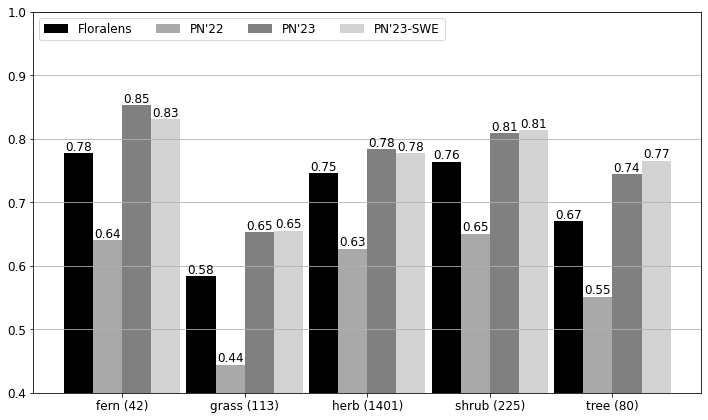

In [6]:
plt = plot_data.plot.bar(x='Category',y=['Floralens','PN\'22', 'PN\'23','PN\'23-SWE'],
                         color=['black','darkgray','gray','lightgray'], width=0.95)
plt.legend(loc='upper left',ncol=4)
plt.set_ylim([0.40,1.0])
plt.set_xlabel('')
plt.grid(axis='y')
plot_data.set_index('Category',inplace=True)
x_labels = ["{} ({})".format(gf,plot_data['# Species'][gf]) for gf in growth_forms]
plt.set_xticklabels(x_labels, rotation=0, ha='center')
for container in plt.containers:
  plt.bar_label(container,fmt='%.2f')
plt.get_figure().tight_layout()
plt.get_figure().savefig('plot_images/plantnet_growth_form_results.pdf') 

## Special status results

In [7]:
status_labels = ['endangered', 'endemic', 'protected', 'rare']
plot_data = pd.DataFrame([
    get_stats_for_species_list(sl, 
                               Common.read_lines_in_file('../flora-on/categories/cs_' + sl + '_species.txt'), 
                               model_results) 
    for sl in status_labels
], columns=['Category', '# Species', 'Floralens', 'PN\'22', 'PN\'23', 'PN\'23-SWE'])  
plot_data

,Category,# Species,Floralens,PN'22,PN'23,PN'23-SWE
0,endangered,152,0.771314,0.663826,0.824008,0.817888
1,endemic,28,0.738889,0.647910,0.767227,0.775739
2,protected,31,0.767078,0.677881,0.785957,0.797428
3,rare,229,0.731259,0.574060,0.735278,0.744219


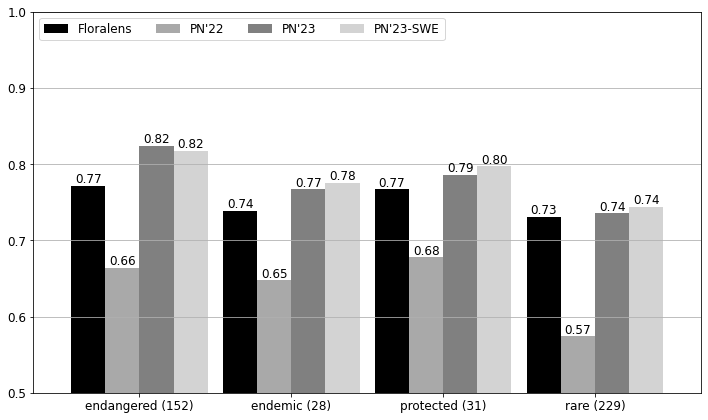

In [8]:
plt = plot_data.plot.bar(x='Category', y=['Floralens','PN\'22', 'PN\'23','PN\'23-SWE'],
                         color=['black','darkgray','gray','lightgray'], width=0.9)
plt.legend(loc='upper left',ncol=4)
plt.set_ylim([0.50,1.0])
plt.set_xlabel('')
plt.grid(axis='y')
plot_data.set_index('Category',inplace=True)
x_labels = ["{} ({})".format(sl, plot_data['# Species'][sl]) for sl in status_labels]
plt.set_xticklabels(x_labels, rotation=0, ha='center')
for container in plt.containers:
  plt.bar_label(container,fmt='%.2f')
plt.get_figure().tight_layout()
plt.get_figure().savefig('plot_images/plantnet_special_status_results.pdf') 